**PHÂN TÍCH COHORT ANALYSIS - BUYER RETENTION RATE**

# I. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# II. Read data

In [3]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#III. Data cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
# xử lý dữ liệu missing/ duplicates: xóa
df.dropna(subset = 'CustomerID', inplace = True)
df.drop_duplicates(inplace = True)

In [9]:
# lấy các dòng quanttity >0
df = df[df['Quantity'] > 0]

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,392732.0,13.153718,1.0,2.0,6.0,12.0,80995.0,181.58842
InvoiceDate,392732,2011-07-10 19:15:24.576301568,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392732.0,3.125596,0.0,1.25,1.95,3.75,8142.75,22.240725
CustomerID,392732.0,15287.734822,12346.0,13955.0,15150.0,16791.0,18287.0,1713.567773


<Axes: xlabel='Quantity'>

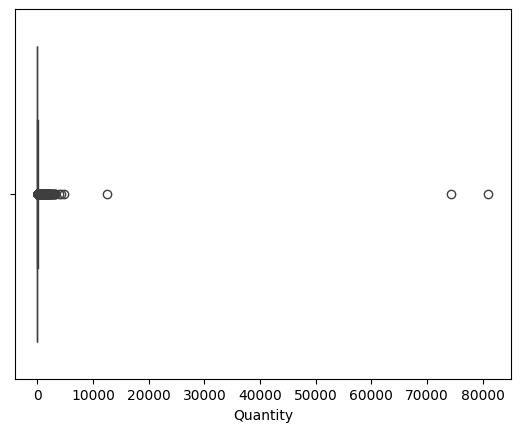

In [11]:
sns.boxplot(data = df
            , x = 'Quantity')

#IV. Cohort Analysis

In [12]:
# tạo bảng cohort mới trên 2 biến điều kiện: InvoiceDate & customerID
df_new = df[['InvoiceDate', 'CustomerID']]
df_new.head()

,InvoiceDate,CustomerID
0,2010-12-01 08:26:00,17850.0
1,2010-12-01 08:26:00,17850.0
2,2010-12-01 08:26:00,17850.0
3,2010-12-01 08:26:00,17850.0
4,2010-12-01 08:26:00,17850.0


In [13]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceDate  392732 non-null  datetime64[ns]
 1   CustomerID   392732 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.0 MB


In [14]:
df_new.isna().sum()

,0
InvoiceDate,0
CustomerID,0


In [15]:
# xóa dòng missing CustomerID
df_new.dropna(subset = 'CustomerID', inplace = True)

/tmp/ipykernel_1590/3368102484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.dropna(subset = 'CustomerID', inplace = True)


In [16]:
df_new.head()

,InvoiceDate,CustomerID
0,2010-12-01 08:26:00,17850.0
1,2010-12-01 08:26:00,17850.0
2,2010-12-01 08:26:00,17850.0
3,2010-12-01 08:26:00,17850.0
4,2010-12-01 08:26:00,17850.0


## B1: Xác định Ngày mua hàng đầu tiên

In [17]:
df_min_date = df_new.groupby('CustomerID', as_index = False).agg(min_InvoiceDate = ('InvoiceDate', 'min'))
df_min_date.head(2)

,CustomerID,min_InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2010-12-07 14:57:00


In [18]:
#tạo bảng precohort lấy  ngày mua hàng đầu tiên = cách merge gtri mindate theo customerID
df_precohort = df_new.merge(df_min_date, on = 'CustomerID', how = 'left')
df_precohort

,InvoiceDate,CustomerID,min_InvoiceDate
0,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00
1,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00
2,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00
3,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00
4,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00
...,...,...,...
392727,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00
392728,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00
392729,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00
392730,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00


## B2: Đo/Tính khoảng cách kể từ ngày mua hàng đầu tiên -> Ngày mua hàng hiện tại là bao lâu (VD: đơn vị tính ~tháng)

In [19]:
#Khoảng cách kể từ ngày PSGD đầu -> hiện tại
df_precohort['DATE_DIFF'] = (df_precohort['InvoiceDate'].dt.year - df_precohort['min_InvoiceDate'].dt.year) * 12 + \
                            (df_precohort['InvoiceDate'].dt.month - df_precohort['min_InvoiceDate'].dt.month)
df_precohort

,InvoiceDate,CustomerID,min_InvoiceDate,DATE_DIFF
0,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0
1,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0
2,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0
3,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0
4,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0
...,...,...,...,...
392727,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4
392728,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4
392729,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4
392730,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4


In [20]:
df_precohort['FIRST_ORDER_MONTH'] = df_precohort['min_InvoiceDate'].dt.to_period('M')
df_precohort

,InvoiceDate,CustomerID,min_InvoiceDate,DATE_DIFF,FIRST_ORDER_MONTH
0,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0,2010-12
1,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0,2010-12
2,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0,2010-12
3,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0,2010-12
4,2010-12-01 08:26:00,17850.0,2010-12-01 08:26:00,0,2010-12
...,...,...,...,...,...
392727,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4,2011-08
392728,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4,2011-08
392729,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4,2011-08
392730,2011-12-09 12:50:00,12680.0,2011-08-18 15:44:00,4,2011-08


## B3: Xây dựng Cohort

- CustomerID: Mã KH => Khách hàng nào quay lại với thời điểm nào

- DATE_DIFF: Khoảng cách từng Lần giao dịch -> Ngày giao dịch lần đầu

- FIRST_ORDER_MONTH: NGày giao dịch đầu tiên (đv: Tháng)

In [21]:
df_cohort_matrix = df_precohort.pivot_table(index  = 'FIRST_ORDER_MONTH'
                        , columns = 'DATE_DIFF'
                        , values = 'CustomerID'
                        , aggfunc = 'nunique')
df_cohort_matrix

DATE_DIFF,0,1,2,3,4,5,6,7,8,9,10,11,12
FIRST_ORDER_MONTH,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## B4: Vẽ heatmap

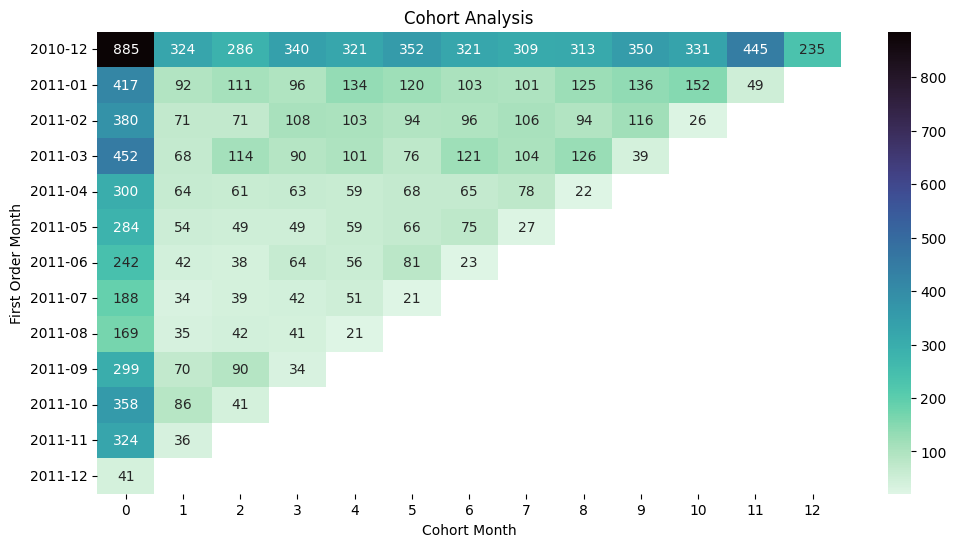

In [22]:
plt.figure(figsize = (12,6))

sns.heatmap(df_cohort_matrix
            , annot = True
            , fmt = 'g'
            , cmap = 'mako_r')

plt.title('Cohort Analysis')
plt.xlabel('Cohort Month')
plt.ylabel('First Order Month')


plt.show()

## B5: Tính toán TỈ LỆ quay lại

In [23]:
cohort_size = df_cohort_matrix.iloc[:, 0]
cohort_size

,0
FIRST_ORDER_MONTH,
2010-12,885.0
2011-01,417.0
2011-02,380.0
2011-03,452.0
2011-04,300.0
2011-05,284.0
2011-06,242.0
2011-07,188.0
2011-08,169.0


In [24]:
df_cohort_matrix_pct = df_cohort_matrix.divide(cohort_size , axis = 0)
df_cohort_matrix_pct

DATE_DIFF,0,1,2,3,4,5,6,7,8,9,10,11,12
FIRST_ORDER_MONTH,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


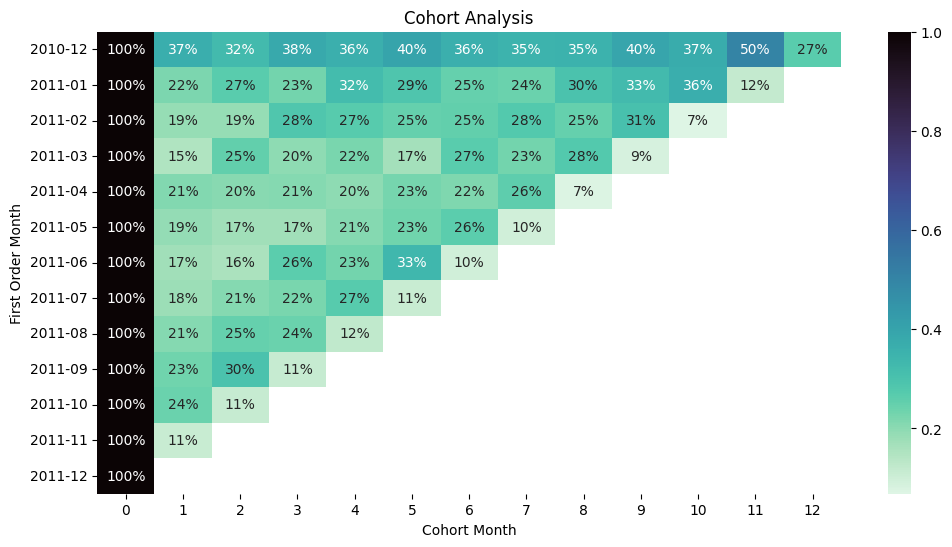

In [25]:
plt.figure(figsize = (12,6))

sns.heatmap(df_cohort_matrix_pct
            , annot = True
            , fmt = '.0%'
            , cmap = 'mako_r')

plt.title('Cohort Analysis')
plt.xlabel('Cohort Month')
plt.ylabel('First Order Month')


plt.show()

In [26]:
#Lấy df mới
df_cohort_matrix_new = df_cohort_matrix

#Lấy số lượng giá trị trống
empty_column = pd.Series([0] * len(df_cohort_matrix), name = 'SLKH')

#Thêm cột trống
df_cohort_matrix_new.insert(loc = 0, column = 'SLKH', value = empty_column)

#Chia để lấy định dạng %
df_cohort_matrix_new_pct = df_cohort_matrix_new.divide(cohort_size, axis = 0)

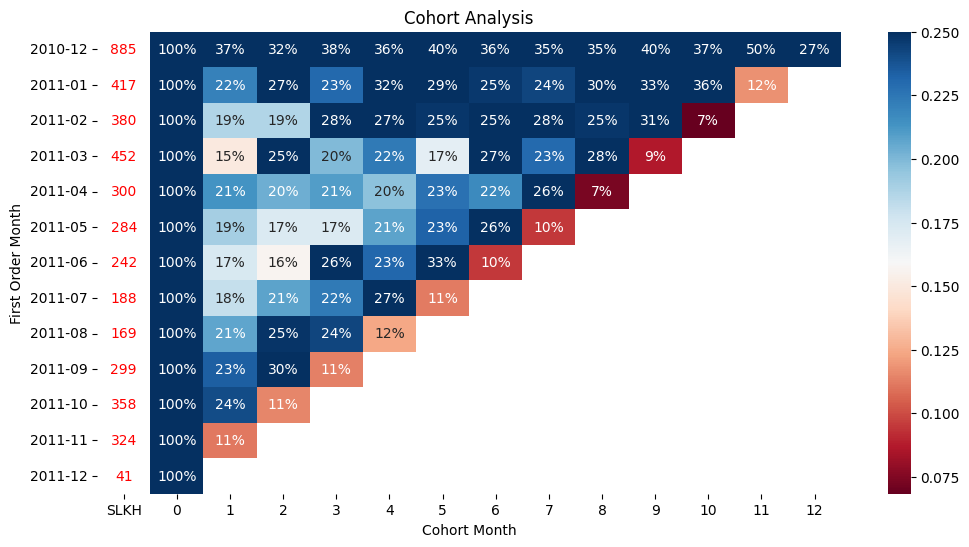

In [28]:
#Vẽ
plt.figure(figsize = (12,6))

sns.heatmap(df_cohort_matrix_new_pct
            , annot = True
            , fmt = '.0%'
            , cmap = 'RdBu'
            , vmax = 0.25)

for i in range (len(df_cohort_matrix)): #Điền số
  plt.text(0.5, i + 0.5, '{:,.0f}'.format(df_cohort_matrix.iloc[i,1]),
           ha = 'center',
           va = 'center',
           color = 'red')

plt.title('Cohort Analysis')
plt.xlabel('Cohort Month')
plt.ylabel('First Order Month')

plt.show()

Nhận xét:

- Số lượng khách hàng mới hàng tháng (~nhìn đường dọc):

  + Xu hướng giảm dần về số lượng khách hàng mới mỗi tháng

  + Thời gian gần đây đang không thu hút được nhiều khách hàng mới. Nếu công ty đang chạy các chiến dịch thu hút khách hàng mới, thì chiến dịch đó đang không đem lại hiệu quả.

- Tỉ lệ giữ chân:

  + Nổi bật là tháng 11/2011, tỉ lệ giữ chân cao nhất so với các tháng khác. Nếu công ty đang triển khai chương trình "giữ chân khách hàng" (tri ân, sinh nhật, ..) thì đang đem lại hiệu quả tốt trong tháng đó. (~nhìn đường chéo)

    => Nhân rộng mô hình của chương trình giữ chân đó

  + Tập khách hàng PSGD lần đầu vào tháng 12/2010 là tập khách hàng chất lượng nhất khi họ có tỉ lệ quay lại trung bình nằm trong khoảng từ 35 - 50% (so với các tháng khác: 15 - 30%) (~nhìn đường ngang)

    => Cần nghiên cứu đặc điểm của những khách hàng PSGD lần đầu vào tháng đó. Đối chiếu xem có gì khác biệt không ..

In [30]:
#CustomerID: Mã KH => Khách hàng nào quay lại với thời điểm nào
df_precohort.groupby('CustomerID')['DATE_DIFF'].apply(list)

,DATE_DIFF
CustomerID,
12346.0,[0]
12347.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
12348.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
12349.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
12350.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...
18280.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
18281.0,"[0, 0, 0, 0, 0, 0, 0]"
18282.0,"[0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4]"


In [36]:
# xem hành vi KH (last_active_month	Khách quay lại xa nhất sau bao nhiêu tháng/
#num_transactions	Tổng số lần mua)
#DATE_DIFF: Khoảng cách từng Lần giao dịch -> Ngày giao dịch lần đầu
df_behavior = df_precohort.groupby('CustomerID').agg({
    'DATE_DIFF': ['max', 'count']
})

df_behavior.columns = ['last_active_month', 'num_transactions']
df_behavior


,last_active_month,num_transactions
CustomerID,,
12346.0,0,1
12347.0,12,182
12348.0,9,31
12349.0,0,73
12350.0,0,17
...,...,...
18280.0,0,10
18281.0,0,7
18282.0,4,12


- KH 12346
last_active_month = 0
num_transactions = 1

=>chỉ mua 1 lần duy nhất
không quay lại → Churn ngay lập tức
- KH 12347
last_active_month = 12
num_transactions = 182

=> mua liên tục 12 tháng, mua rất nhiều
→ Khách VIP / cực kỳ trung thành
- KH 12349
last_active_month = 0
num_transactions = 73

mua rất nhiều, nhưng chỉ trong 1 tháng duy nhất
 → Có thể:
mua bulk (mua sỉ)
hoặc campaign ngắn hạn

=> nhưng không quay lại → churn

- KH 18283
last_active_month = 11
num_transactions = 721
→ Siêu VIP luôn vì hành vi có tính liên tục lặp lại -> khách này rất có gtri

==> Phần lớn khách hàng chỉ giao dịch trong tháng đầu tiên (last_active_month = 0), cho thấy tỷ lệ giữ chân khách hàng thấp.
Tuy nhiên, tồn tại một nhóm nhỏ khách hàng có tần suất giao dịch cao và hoạt động kéo dài nhiều tháng, đóng vai trò là nhóm khách hàng giá trị cao (VIP).
Đáng chú ý, có những khách hàng có số lượng giao dịch lớn nhưng không quay lại sau tháng đầu tiên, cho thấy nguy cơ mất khách hàng giá trị cao.